# ⏱️ Time series: trend, seasonality, decomposition. 

---

# What is a Time Series?

A **time series** is a set of observations collected at regular (or known) points in time. Unlike ordinary tables where row order doesn’t matter, **order is everything** here: values depend on what came before (autocorrelation). In energy, typical examples are **hourly demand, wind output, PV irradiance, prices**.

### 📅 Calendar & Index Hygiene

Set a proper `DatetimeIndex`, ensure **regular frequency** (e.g., `freq='h'`), and verify time zone if relevant. Gaps or duplicated timestamps will **break lags/rolling** silently. Use:

* **Sorting** by time before any lag/rolling.
* **Reindexing** to the expected full range to surface missing hours.
  This avoids subtle data leakage later.


In [646]:
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR,LinearSVR


import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.seasonal import seasonal_decompose


import warnings
warnings.filterwarnings("ignore")

# Data
## Loading data

In [647]:
australia = pd.read_excel('data/Australia_electricty_data.xlsx')
australia = australia.rename(columns={"Unnamed: 0":"datetime", "Electricity [GWh]": "electricity"})
australia.set_index('datetime',inplace=True)
#plt.style.use("seaborn-whitegrid")
#plt.figure(figsize=(10,5))
#p=sns.lineplot(data= australia);
#p.set_ylabel("Consumption [GWh]", fontsize = 18);
#p.set_xlabel("Quarters of the year", fontsize = 18);
#plt.xticks(fontsize=12)
#plt.yticks(fontsize=13)
#plt.legend('', frameon=False);

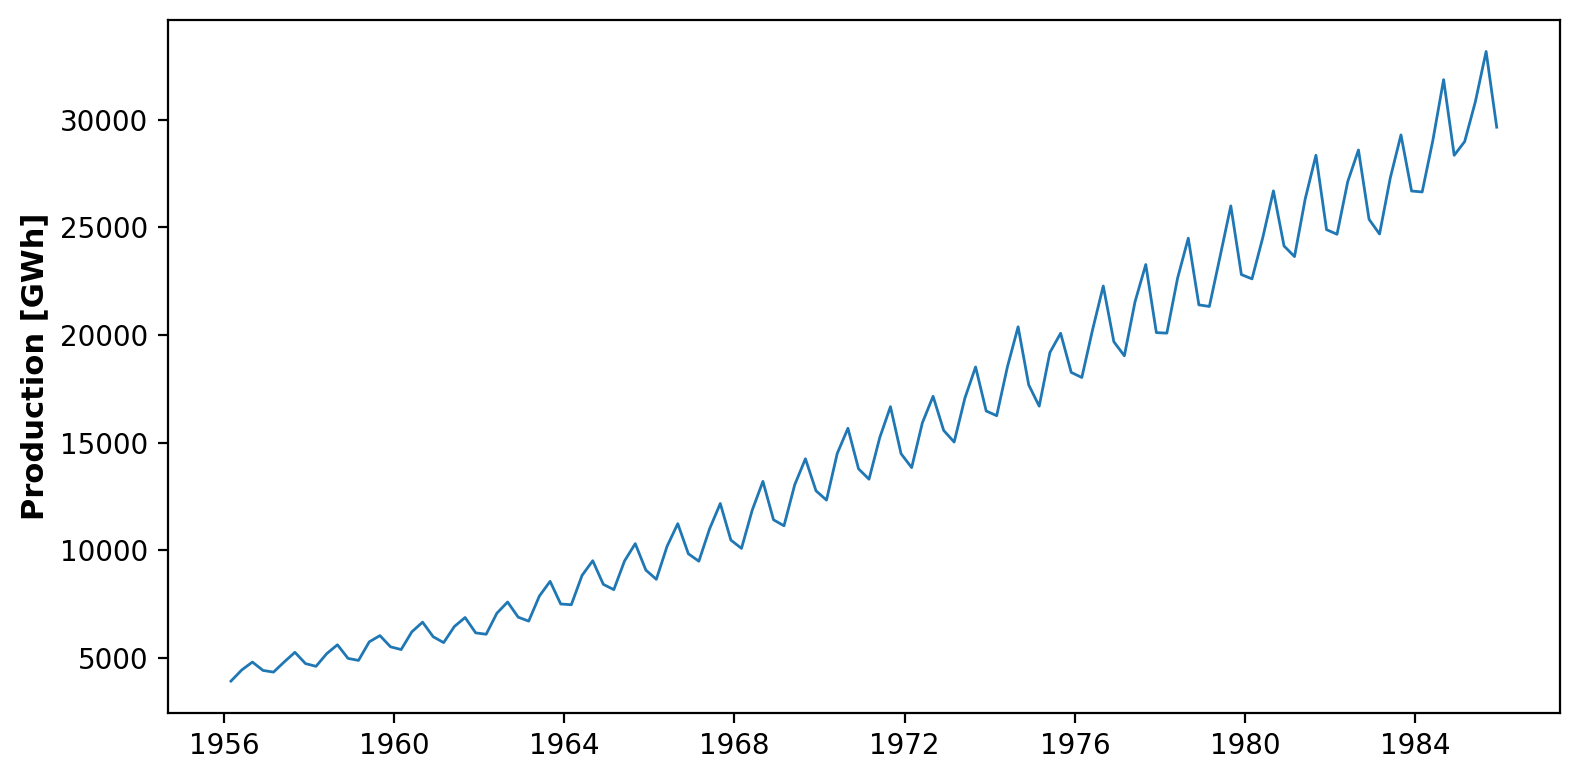

In [648]:
# Crop
australia = australia.loc['1956-03-01':'1985-12-01']
plt.figure(figsize=(8, 4))
plt.plot(australia['electricity'], lw=1)
plt.ylabel('Production [GWh]', fontsize=11)
plt.show()

In [649]:
elering = pd.read_csv('data/electricity-production and consumption_2022.csv',  delimiter=';',decimal=',')
elering['timestamp'] = pd.to_datetime(elering['Kuupaev (Eesti aeg)'], dayfirst=True)

demand = elering[['timestamp', 'Tarbimine']]
demand.set_index('timestamp', inplace=True)
demand = demand.rename(columns = {'Tarbimine':'demand'})
demand.head()

,demand
timestamp,
2022-01-01 00:00:00,899.4
2022-01-01 01:00:00,892.1
2022-01-01 02:00:00,874.3
2022-01-01 03:00:00,860.1
2022-01-01 04:00:00,842.7



# ⏱️ Features Unique to Time Series

Unlike “ordinary” tabular data, time series have **special structure**: order and dependency in time. This gives rise to two **unique kinds of features**:

---

### Time-Step Features (Calendar/Index-Based) 📅

These come directly from the **timestamp** of each observation, not from the values.

---

### Lag Features (Value-Based) 🔁

These use the **past values of the target variable (or other variables)** as predictors.



# Tools
## 🔁 Lags and shifts

Lags capture the **memory** of a time series — the idea that the **present is influenced by the past**. In energy systems, yesterday’s evening peak often predicts today’s evening peak, and last week’s Monday pattern is a good indicator for this week’s Monday.

### 📌 Typical Lags in Energy Data

* **`lag1`** → one step back (1 hour ago). Useful for **short-term persistence**.
* **`lag24`** → same hour yesterday. Captures **daily cycles** (day–night demand patterns).
* **`lag168`** → same hour last week. Captures **weekly cycles** (workdays vs weekends).

💡 You can also create other domain-specific lags, e.g.:

* `lag720` (same hour last month) for monthly seasonality.
* Lagged weather features: yesterday’s average temperature may explain today’s heating demand.

---

### 🧮 Mathematical Notation

The lecture introduces the **backshift operator** $B$:

* $B y_t = y_{t-1}$ → one-step lag
* $B^{24} y_t = y_{t-24}$ → daily lag
* $B^{168} y_t = y_{t-168}$ → weekly lag

This compact notation helps define models like AR (autoregressive) processes:

$$
y_t = \phi_1 B y_t + \phi_2 B^2 y_t + \dots + \epsilon_t
$$

---

### ⚠️ Causality and Leakage

Be strict about **causality**:

* Always use **past values** to predict the future.
* When you shift the series to create lags, the first rows will become `NaN`.
* Drop those rows before training, otherwise you leak future information into the past.

---

### ⚡ Energy Example

Suppose we want to forecast **electricity demand at 18:00**:

* `lag1` = demand at 17:00 (captures short persistence).
* `lag24` = demand at 18:00 yesterday (captures daily cycle).
* `lag168` = demand at 18:00 one week ago (captures weekly cycle).

These features together give the model a **memory of recent and recurring patterns**.

---

✅ **Summary:**

* Lag features = shifted copies of the series.
* Capture short-term memory (`lag1`), daily repetition (`lag24`), and weekly cycles (`lag168`).
* Use the backshift operator $B$ to describe them mathematically.
* Always enforce causality by dropping rows with missing lags.



In [650]:
demand_lag1h = demand[['demand']].shift(1)
demand_lag1h = demand_lag1h.rename(columns = {'demand':'lag1h'})
demand_lags = demand.join(demand_lag1h)

In [651]:
demand_lag2h = demand[['demand']].shift(2)
demand_lag2h = demand_lag2h.rename(columns = {'demand':'lag2h'})
demand_lags = demand_lags.join(demand_lag2h)
demand_lags

,demand,lag1h,lag2h
timestamp,,,
2022-01-01 00:00:00,899.4,NaN,NaN
2022-01-01 01:00:00,892.1,899.4,NaN
2022-01-01 02:00:00,874.3,892.1,899.4
2022-01-01 03:00:00,860.1,874.3,892.1
2022-01-01 04:00:00,842.7,860.1,874.3
...,...,...,...
2022-12-31 19:00:00,989.4,1042.8,1085.3
2022-12-31 20:00:00,932.5,989.4,1042.8
2022-12-31 21:00:00,889.5,932.5,989.4


## 📊 Rolling Statistics (Moving Averages)

Rolling statistics are another way of giving a model **context from the past**, but instead of looking at a single lagged value, they summarize behavior over a **window of time**. This smooths out short-term fluctuations and reveals the **underlying signal**.

---
### 🔢 Mathematical Form (Simple Moving Average)

For a rolling mean with window size $w$:

$$
\overline{y}_{t,w} = \frac{1}{w}\sum_{i=0}^{w-1} y_{t-i}
$$

Example: if $w = 24$, the average of the last 24 hourly demands becomes the new feature.

---

### 📅 Choosing Window Sizes

The window should reflect the **operational cycle** you want to capture:

* **24 (hours)** → smooths intra-day fluctuations → daily baseline demand.
* **168 (hours)** → smooths week-to-week variations → weekly load pattern.
* **720 (hours ≈ 30 days)** → smooths monthly fluctuations.

**Rule of thumb:** start with domain knowledge (daily/weekly cycles in energy), then adjust based on data.

---

#### ⚠️ Things to Watch Out For

* Rolling features introduce **NA values at the start** of the series (drop them).
* Use **causal windows** (past only), not centered windows, to avoid leakage.
* Too large a window can smooth out important short-term variations.

In [652]:
australia.head(10)

,electricity
datetime,
1956-03-01,3923
1956-06-01,4436
1956-09-01,4806
1956-12-01,4418
1957-03-01,4339
1957-06-01,4811
1957-09-01,5259
1957-12-01,4735
1958-03-01,4608


### 📊 What is a 3-Month Moving Average (3MA)?

A **3-period moving average** (3MA) smooths a time series by replacing each value with the **average of itself and the two neighboring values**.

* It reduces random fluctuations.
* It highlights the **underlying trend**.
* It’s especially common in **monthly data** (hence “3-month”), but the same idea applies to any frequency (3-day, 3-hour, etc.).

---

#### 🔢 Formula

For a 3-point moving average, at time $t$:

$$
MA_t = \frac{y_{t-1} + y_t + y_{t+1}}{3}
$$

⚠️ This is a **centered moving average** — it uses one past, one present, and one future observation.

For forecasting, we usually prefer a **trailing moving average** (past-only):

$$
MA_t = \frac{y_t + y_{t-1} + y_{t-2}}{3}
$$

---

#### 🧮 Relation to Decomposition

* 3MA is the simplest tool for **trend extraction**.
* In **seasonal decomposition**, longer MAs are used (e.g., 12MA for monthly data, 2×4MA for quarterly).
* Still, 3MA is a great entry point for teaching smoothing.

---


✅ **Summary:**

* 3MA is a simple way to smooth noise and reveal the trend.
* Works on any frequency, but popular for monthly/quarterly data.
* Best for analysis and visualization, less for real-time forecasting.


In [653]:
ma3 = australia['electricity'].rolling(3).mean().round(2).to_frame().shift(-1)
ma3 = ma3.rename(columns = {'electricity':'3-ma'})
ma3.set_index(australia.index,inplace=True)
ma_ex = australia.join(ma3)
ma_ex.head(10)

,electricity,3-ma
datetime,,
1956-03-01,3923,NaN
1956-06-01,4436,4388.33
1956-09-01,4806,4553.33
1956-12-01,4418,4521.00
1957-03-01,4339,4522.67
1957-06-01,4811,4803.00
1957-09-01,5259,4935.00
1957-12-01,4735,4867.33
1958-03-01,4608,4846.33


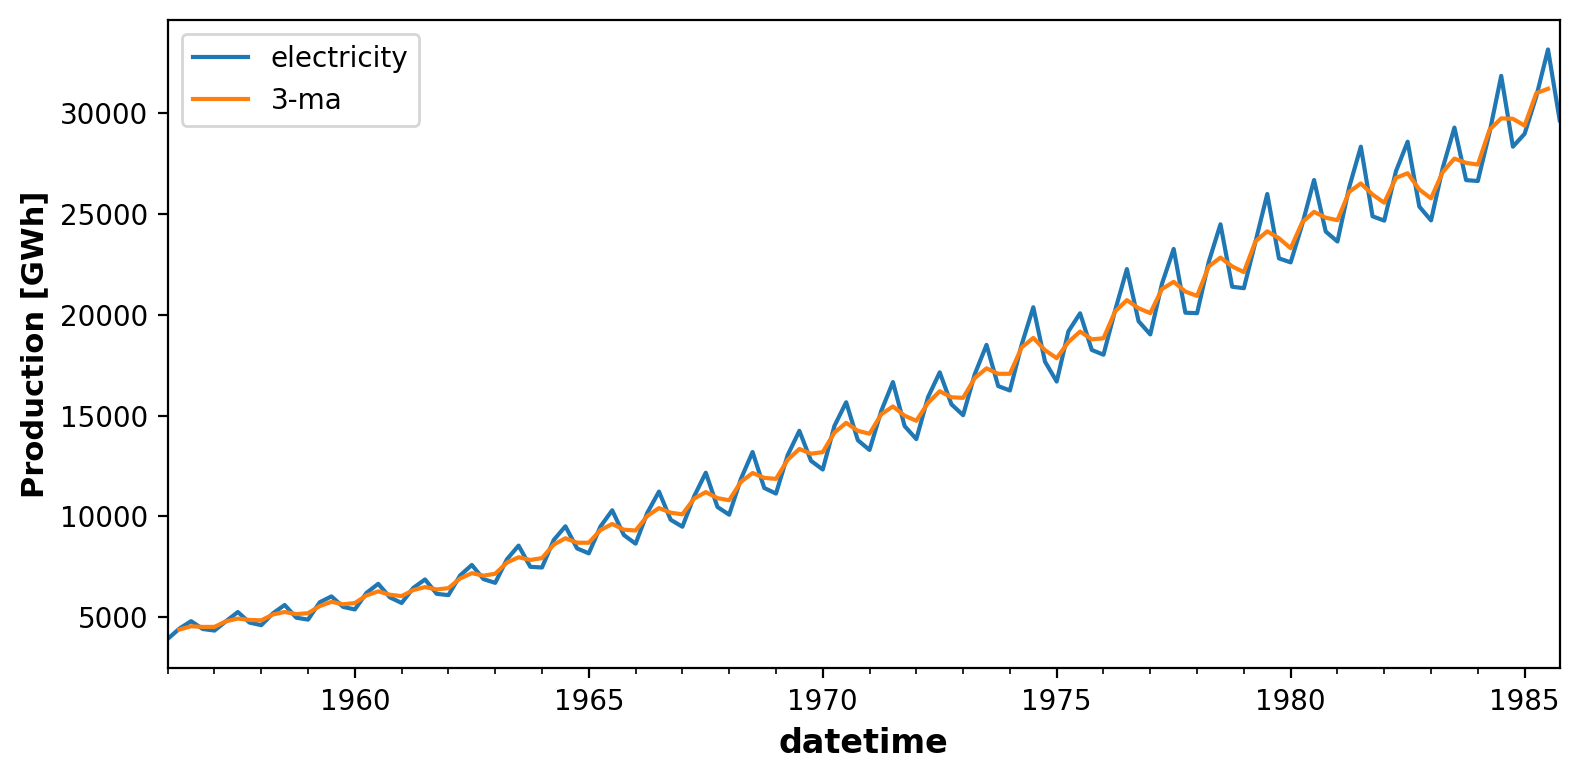

In [654]:
ma_ex[['electricity', '3-ma']].plot(label='production', 
                                  figsize=(8, 4))
plt.ylabel('Production [GWh]', fontsize=11);

### 📊 What is a 5-Point Moving Average (5MA)?

A **5-period moving average** smooths a time series by averaging **five consecutive values**.

* It reduces noise more strongly than 3MA.
* It captures the **trend** while filtering out short-term fluctuations.
* It’s often used with **monthly data** (5-month average) or **daily/hourly data** (5-day or 5-hour average).

---

#### 🔢 Formula

For a **centered 5MA**:

$$
MA_t = \frac{y_{t-2} + y_{t-1} + y_t + y_{t+1} + y_{t+2}}{5}
$$

For a **trailing 5MA** (past-only, more useful for forecasting):

$$
MA_t = \frac{y_t + y_{t-1} + y_{t-2} + y_{t-3} + y_{t-4}}{5}
$$


---

#### 🧮 Role in Decomposition

* 5MA is more aggressive at smoothing than 3MA.
* Often used as an intermediate step before extracting seasonal effects.
* The longer the MA, the smoother the trend, but risk losing detail.

---

#### ⚠️ Things to Watch Out For

* **Centered 5MA** uses future values → good for analysis, not for forecasting.
* **Trailing 5MA** is causal, but it lags behind the actual trend.
* Window length should reflect the **dominant cycle** (daily, weekly, seasonal).


In [655]:
ma5 = australia['electricity'].rolling(5).mean().round(2).to_frame()
ma5 = ma5.rename(columns = {'electricity':'5-ma'})
ma5.set_index(australia.index,inplace=True)
ma_ex = ma_ex.join(ma5)
ma_ex.head(10)

,electricity,3-ma,5-ma
datetime,,,
1956-03-01,3923,NaN,NaN
1956-06-01,4436,4388.33,NaN
1956-09-01,4806,4553.33,NaN
1956-12-01,4418,4521.00,NaN
1957-03-01,4339,4522.67,4384.4
1957-06-01,4811,4803.00,4562.0
1957-09-01,5259,4935.00,4726.6
1957-12-01,4735,4867.33,4712.4
1958-03-01,4608,4846.33,4750.4


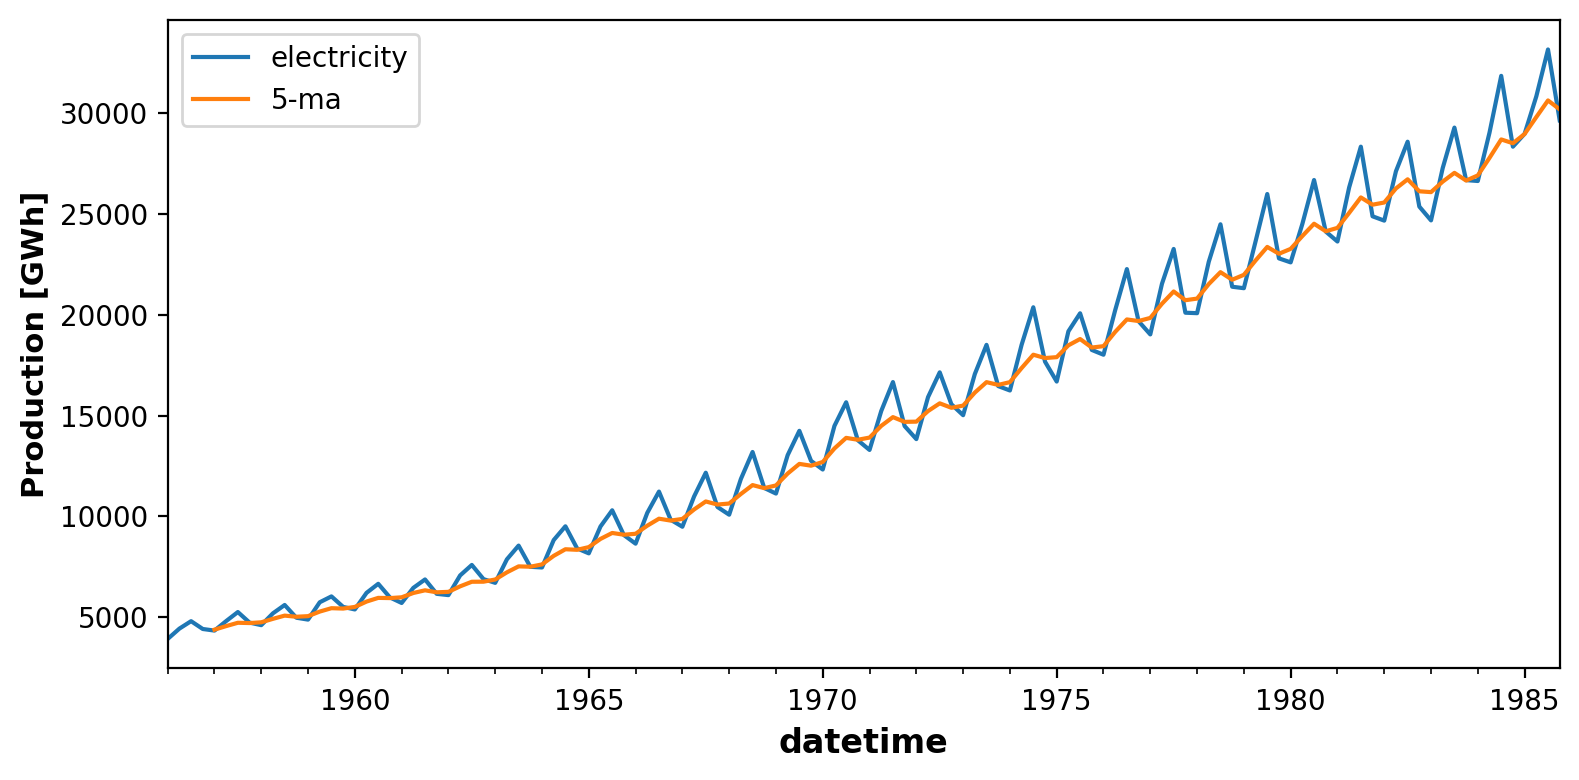

In [656]:
ma_ex[['electricity', '5-ma']].plot(label='production', 
                                  figsize=(8, 4))
plt.ylabel('Production [GWh]', fontsize=11);



### 📊 What is a 2×4 Moving Average (2×4MA)?

A **2×4MA** is a two-stage moving average:

1. First, take a **4-point moving average** (4MA).
2. Then, take a **2-point moving average** of those results.

This is often used with **quarterly data** to smooth seasonal fluctuations across a full year (4 quarters).

---


#### 🔢 Formula

1. Compute the 4MA:

$$
MA^{(4)}_t = \frac{y_{t-1} + y_t + y_{t+1} + y_{t+2}}{4}
$$

2. Then apply a 2MA:

$$
MA^{(2 \times 4)}_t = \frac{MA^{(4)}_{t} + MA^{(4)}_{t+1}}{2}
$$

---

#### ⚡ Example

Suppose we have **quarterly electricity demand (TWh)**:

| Quarter | Demand |
| ------- | ------ |
| Q1      | 120    |
| Q2      | 140    |
| Q3      | 130    |
| Q4      | 150    |
| Q5      | 160    |
| Q6      | 170    |

1. Compute 4MA (centered between quarters):

* 4MA(Q2–Q5) = (140+130+150+160)/4 = 145

2. Apply 2MA to adjacent 4MAs to re-center:

* 2×4MA(Q3) = (4MA(Q2–Q5) + 4MA(Q3–Q6))/2

Now the smoothed value is properly aligned with **Q3**, representing the annual trend-cycle at that quarter.

---

#### 🧮 Role in Decomposition

* **Quarterly data** has 4 periods per year.
* To extract the **trend-cycle** (remove seasonality), a 4-quarter moving average is natural.
* But because 4 is even, we need the **2×4MA** to properly center.
* This method is central to **classical decomposition** (trend + seasonal + irregular).

---

#### ⚠️ Things to Watch Out For

* 2×4MA is **centered**, so it uses both past and future observations → good for analysis, not forecasting.
* For real-time forecasting, use **trailing MAs** instead.

---

✅ **Summary:**

* 2×4MA = 4MA followed by 2MA → re-centers the moving average.
* Used with **quarterly data** to estimate the trend-cycle.
* Essential step in **seasonal decomposition** when the seasonal period is even.


In [657]:
ma4 = australia['electricity'].rolling(4).mean().round(2).to_frame()
ma4 = ma4.rename(columns = {'electricity':'4-ma'})
ma4.set_index(australia.index,inplace=True)
ma_ex = ma_ex.join(ma4)
ma_ex.head(10)

,electricity,3-ma,5-ma,4-ma
datetime,,,,
1956-03-01,3923,NaN,NaN,NaN
1956-06-01,4436,4388.33,NaN,NaN
1956-09-01,4806,4553.33,NaN,NaN
1956-12-01,4418,4521.00,NaN,4395.75
1957-03-01,4339,4522.67,4384.4,4499.75
1957-06-01,4811,4803.00,4562.0,4593.50
1957-09-01,5259,4935.00,4726.6,4706.75
1957-12-01,4735,4867.33,4712.4,4786.00
1958-03-01,4608,4846.33,4750.4,4853.25


In [658]:
ma24 = ma_ex['4-ma'].rolling(2).mean().round(2).to_frame()
ma24 = ma24.rename(columns = {'4-ma':'2x4-ma'})
ma24.set_index(australia.index,inplace=True)
ma_ex = ma_ex.join(ma24)
ma_ex.head(10)

,electricity,3-ma,5-ma,4-ma,2x4-ma
datetime,,,,,
1956-03-01,3923,NaN,NaN,NaN,NaN
1956-06-01,4436,4388.33,NaN,NaN,NaN
1956-09-01,4806,4553.33,NaN,NaN,NaN
1956-12-01,4418,4521.00,NaN,4395.75,NaN
1957-03-01,4339,4522.67,4384.4,4499.75,4447.75
1957-06-01,4811,4803.00,4562.0,4593.50,4546.62
1957-09-01,5259,4935.00,4726.6,4706.75,4650.12
1957-12-01,4735,4867.33,4712.4,4786.00,4746.38
1958-03-01,4608,4846.33,4750.4,4853.25,4819.62


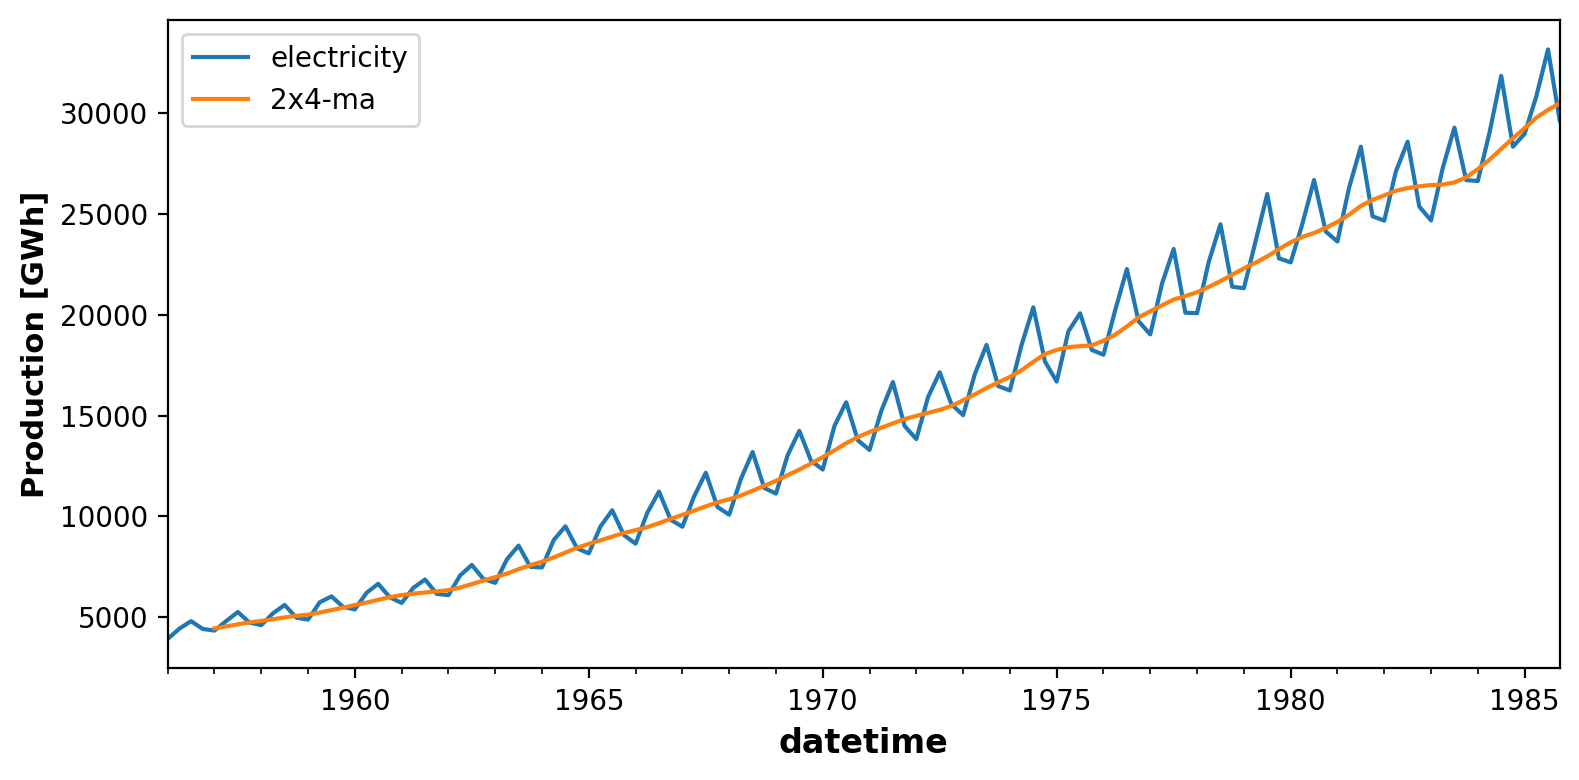

In [659]:
ma_ex[['electricity', '2x4-ma']].plot(label='production', 
                                  figsize=(8, 4))
plt.ylabel('Production [GWh]', fontsize=11);

# 🧩 Components: Trend • Seasonality • Cycles • Irregular

Decompose a series into:

* **Trend**: long-run increase/decrease (e.g., electrification).
* **Seasonality**: fixed-frequency patterns (hourly/daily/weekly/annual).
* **Cycle**: recurring but not fixed-length (e.g., business cycles).
* **Irregular**: shocks, holidays, outages.
  Knowing your components guides **features** and **models** (seasonal lags, holiday flags).

---

## 🪄 Additive vs Multiplicative Patterns

If seasonal amplitude is roughly **constant**, an **additive** view fits: $y_t = T_t + S_t + R_t$.
If amplitude **scales with level**, prefer **multiplicative**: $y_t = T_t \times S_t \times R_t$.
A log transform converts multiplicative relations to additive, making them easier to model or decompose.

## 🧱 Decomposition: Why Visualize It?

Decomposition (trend/seasonal/remainder) explains **why** your model needs certain features:

* Large seasonal component → use **seasonal lags** and **cyclical encodings**.
* Strong trend → consider **differencing** or trend features.
* Large remainder → consider **holiday/outage** flags.

<Figure size 1000x400 with 0 Axes>

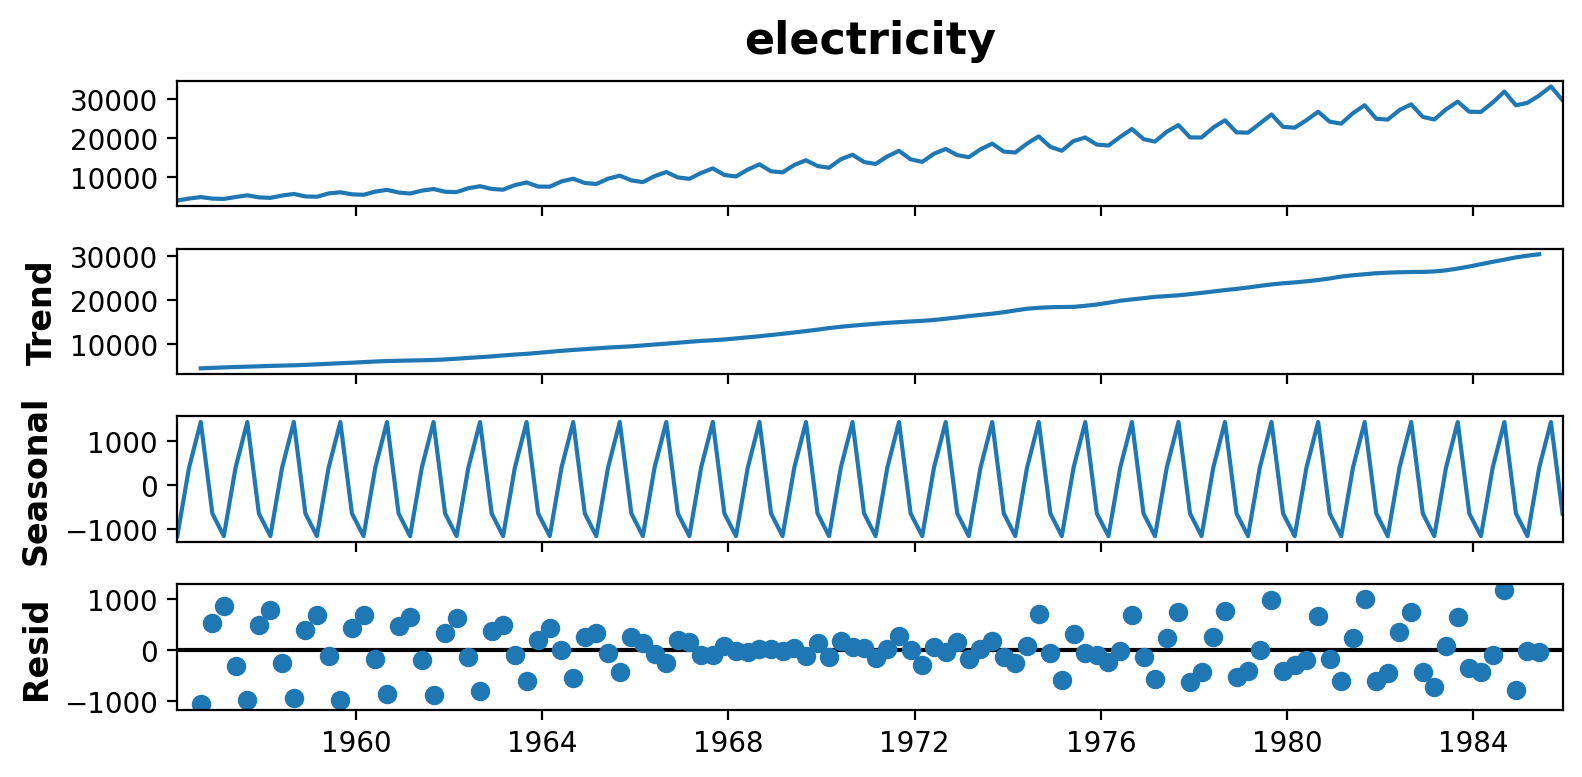

In [660]:
result = seasonal_decompose(australia['electricity'], model='additive', period=4)
plt.figure(figsize=(10,4));
result.plot();

# 📈 Trend

**Definition:** Features that capture the **long-term increase or decrease** in the series.

Trends reflect **structural changes** in energy systems:

* 📉 Decline in fossil fuel usage.
* 📈 Growth in electrification, EV adoption, and heat pumps.
* 💶 Energy prices drifting upward due to market conditions.

### How to engineer trend features

* **Time index as a numeric variable** → e.g., days since start.
* **Rolling averages** → smooth out short-term noise to highlight trend.
* **Detrending** → remove trend first, then model residuals.
* **Polynomial trend terms** → quadratic or cubic trends if growth is nonlinear.


In [661]:
australia['time'] = np.arange(len(australia.index))
australia.head()

,electricity,time
datetime,,
1956-03-01,3923,0
1956-06-01,4436,1
1956-09-01,4806,2
1956-12-01,4418,3
1957-03-01,4339,4


## 📈 Linear Regression with a Time-Step Feature

One of the simplest ways to capture **trend** in a time series is by using **time itself as a predictor**.

We assume the target evolves approximately as a **linear function of time**:

$$
y_t = \text{weight} \times t + \text{bias} + \epsilon_t
$$

* `time (t)` → the time-step feature (e.g., hours since start).
* `weight` → slope, representing the **rate of change** (trend).
* `bias` → intercept, the baseline level at the start.
* `ε` → error term (irregular fluctuations not explained by trend).


✅ **Summary**

* Linear regression on a time-step feature = modeling the **trend component**.
* Useful as a **baseline model**.
* Limitations: can’t capture seasonality or nonlinear patterns, but easy to interpret.



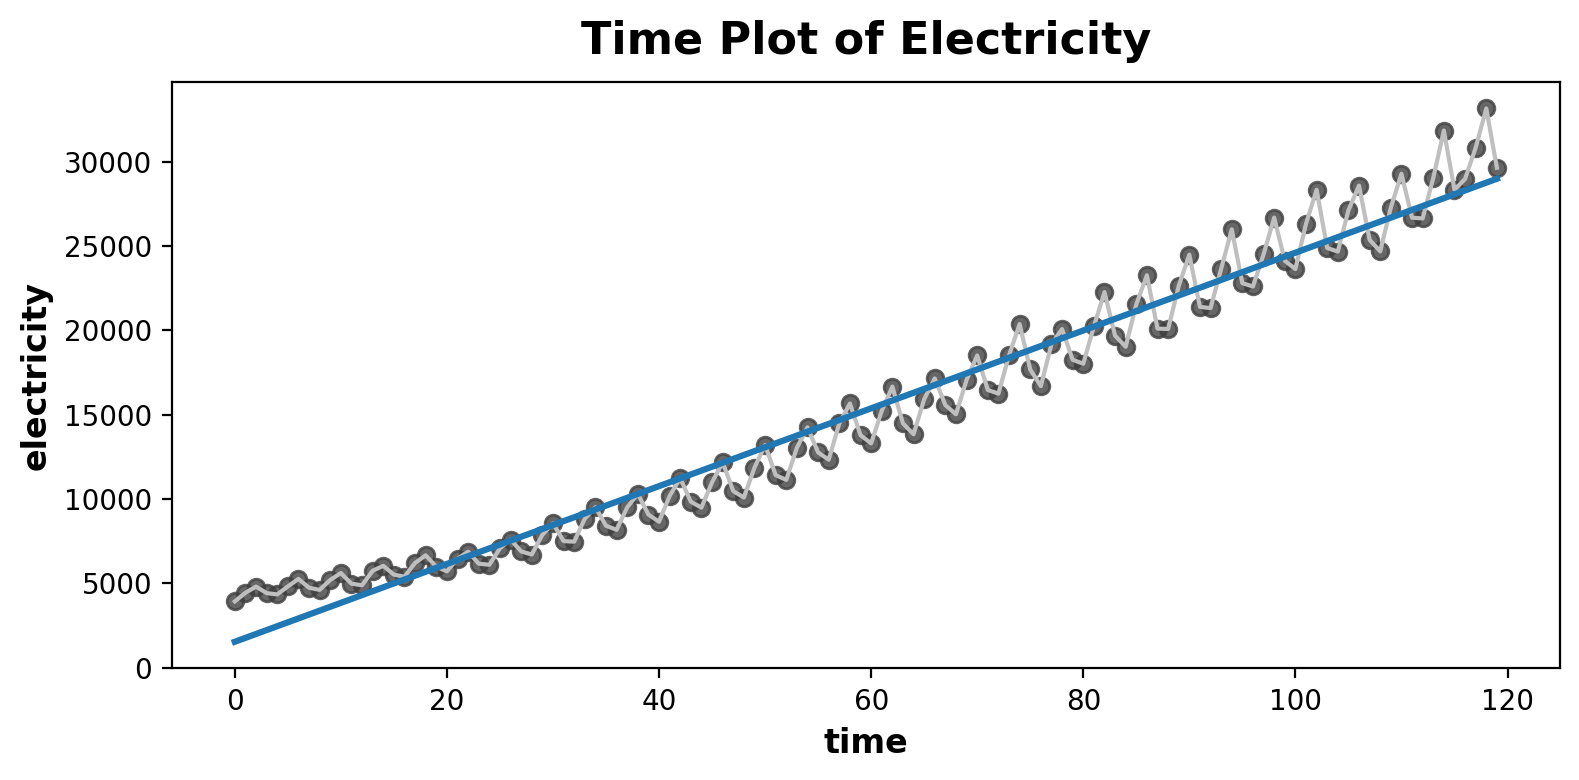

In [662]:
#plt.style.use("seaborn-whitegrid")
plt.rc(
    "figure",
    autolayout=True,
    figsize=(8, 4),
    titlesize=18,
    titleweight='bold',
)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
#%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots()
ax.plot('time', 'electricity', data=australia, color='0.75')
ax = sns.regplot(x='time', y='electricity', data=australia, ci=None, scatter_kws=dict(color='0.25'))
ax.set_title('Time Plot of Electricity');

In [663]:
# Training data
X = australia.loc[:, ['time']]  # features
y = australia.loc[:, 'electricity']  # target

# Train the model
model = LinearRegression()
model.fit(X, y)

# Store the fitted values as a time series with the same time index as
# the training data
y_pred = pd.Series(model.predict(X), index=X.index)

print('Slope :', model.coef_)
print('\nIntercept Value:', model.intercept_)

Slope : [230.78789499]

Intercept Value: 1530.4702479338812


## DeterministicProcess
### Linear trend

In [664]:
dp = DeterministicProcess(
    index=australia.index,  # dates from the training data
    constant=True,       # dummy feature for the bias (y_intercept)
    order=1,             # the time dummy (trend)
    drop=True,           # drop terms if necessary to avoid collinearity
)
# `in_sample` creates features for the dates given in the `index` argument
X = dp.in_sample()

X.head()

,const,trend
datetime,,
1956-03-01,1.0,1.0
1956-06-01,1.0,2.0
1956-09-01,1.0,3.0
1956-12-01,1.0,4.0
1957-03-01,1.0,5.0


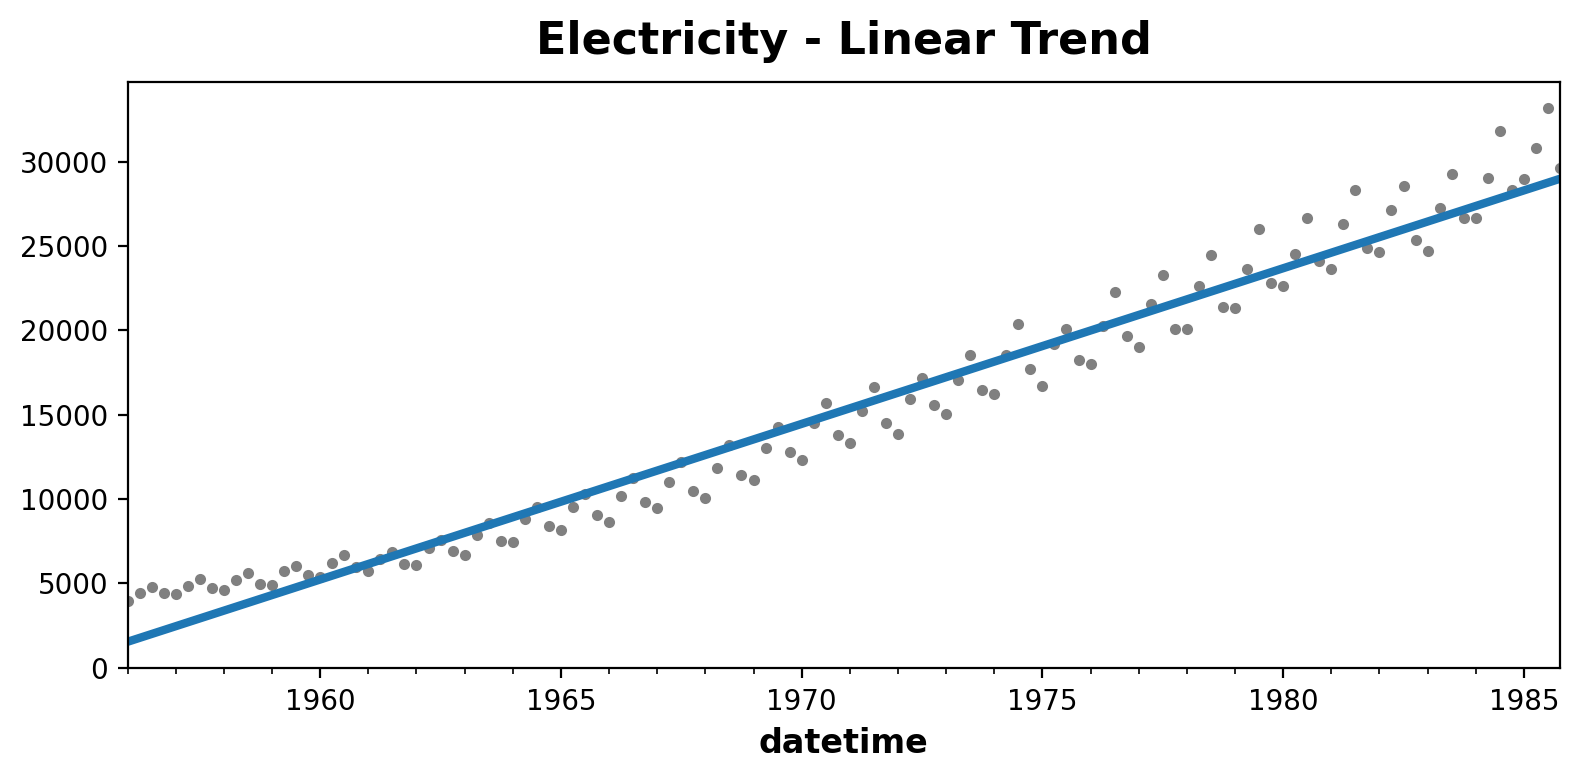

In [665]:
y = australia["electricity"]  # the target

# The intercept is the same as the `const` feature from
# DeterministicProcess. LinearRegression behaves badly with duplicated
# features, so we need to be sure to exclude it here.
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

ax = australia['electricity'].plot(style=".", color="0.5", title="Electricity - Linear Trend")
_ = y_pred.plot(ax=ax, linewidth=3, label="Trend")

### Non-linear trend

In [666]:
dp = DeterministicProcess(
    index=australia.index,  # dates from the training data
    constant=True,       # dummy feature for the bias (y_intercept)
    order=3,             # the time dummy (trend)
    drop=True,           # drop terms if necessary to avoid collinearity
)
# `in_sample` creates features for the dates given in the `index` argument
X = dp.in_sample()

X.head()

,const,trend,trend_squared,trend_cubed
datetime,,,,
1956-03-01,1.0,1.0,1.0,1.0
1956-06-01,1.0,2.0,4.0,8.0
1956-09-01,1.0,3.0,9.0,27.0
1956-12-01,1.0,4.0,16.0,64.0
1957-03-01,1.0,5.0,25.0,125.0


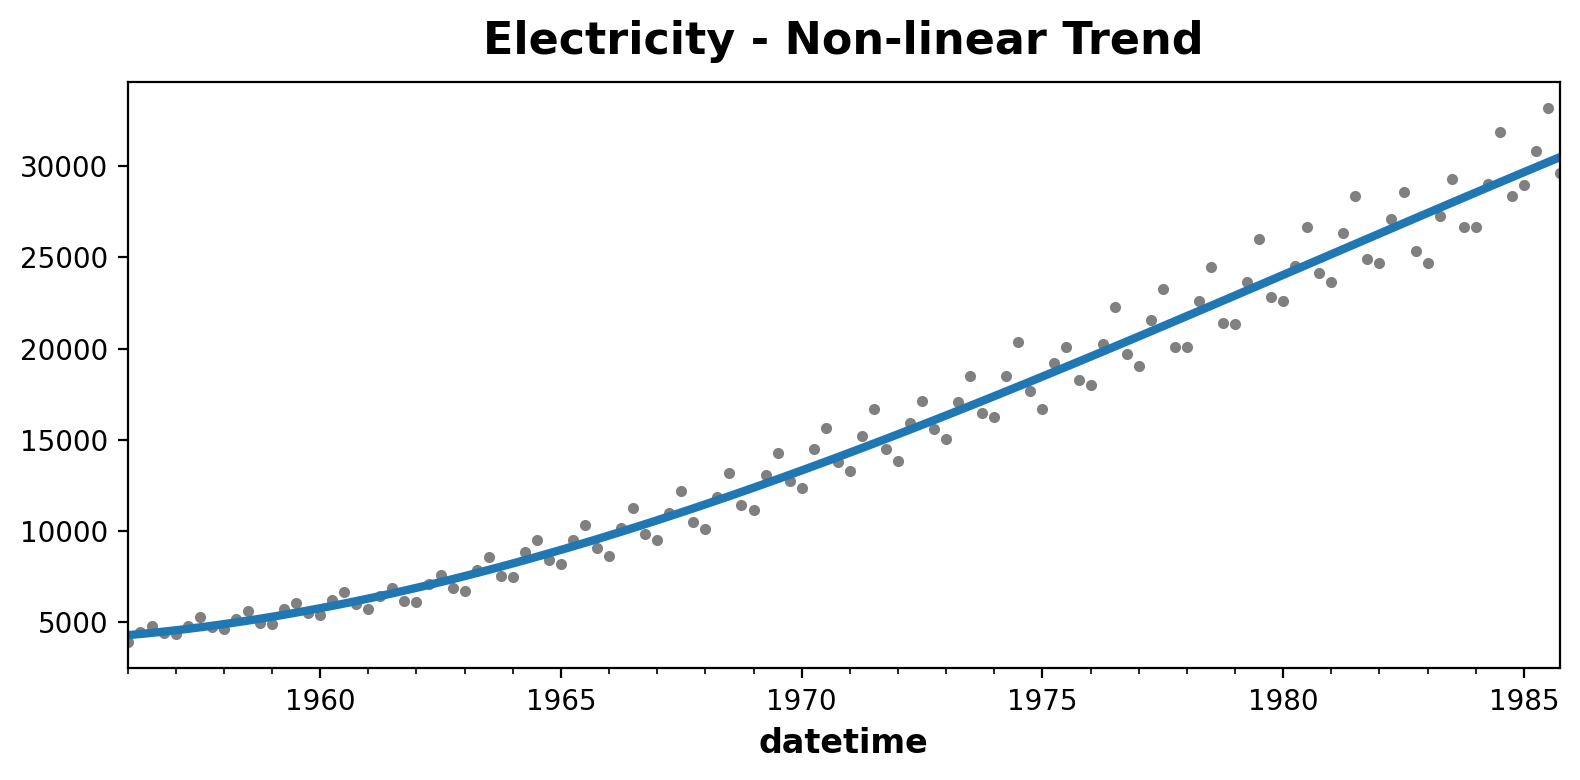

In [667]:
y = australia["electricity"]  # the target

# The intercept is the same as the `const` feature from
# DeterministicProcess. LinearRegression behaves badly with duplicated
# features, so we need to be sure to exclude it here.
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

ax = australia['electricity'].plot(style=".", color="0.5", title="Electricity - Non-linear Trend")
_ = y_pred.plot(ax=ax, linewidth=3, label="Trend")

## Trend from seasonal decomposition

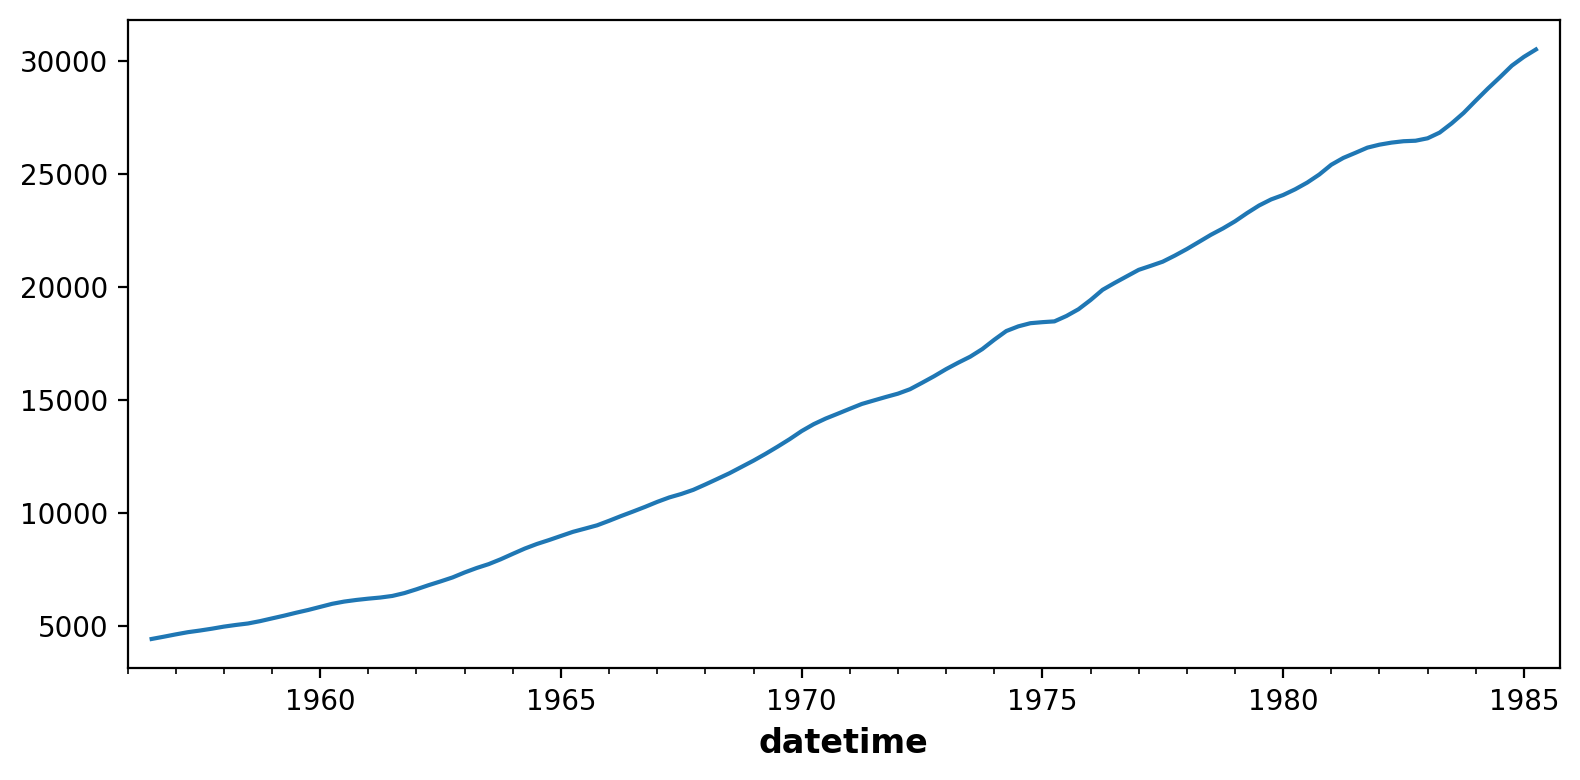

In [668]:
result=seasonal_decompose(australia['electricity'], model='additive', period=4)
#fig=result.plot()

plt.figure(figsize=(8,4))
result.trend.plot();

#  🧮 Seasonality

**Seasonality** refers to **repeated patterns** in a time series that occur at **regular intervals**. Unlike trend (which is long-term drift), seasonality is **cyclical and predictable**.

---

### 🔹 What is Seasonality?

* A **systematic, calendar-related movement** in data.
* Patterns repeat after a **fixed period**: hourly, daily, weekly, yearly.
* Driven by human activity, nature, or markets.

Mathematically:

$$
y_t = T_t + S_t + R_t
$$

where $S_t$ is the seasonal component.

---

### 🔹 Types of Seasonality

1. **Daily (intraday)** → electricity demand peaks in morning & evening, drops at night.
2. **Weekly** → weekdays (higher demand) vs weekends (lower demand).
3. **Annual** → winter heating, summer cooling, holiday effects.



## Patterns 

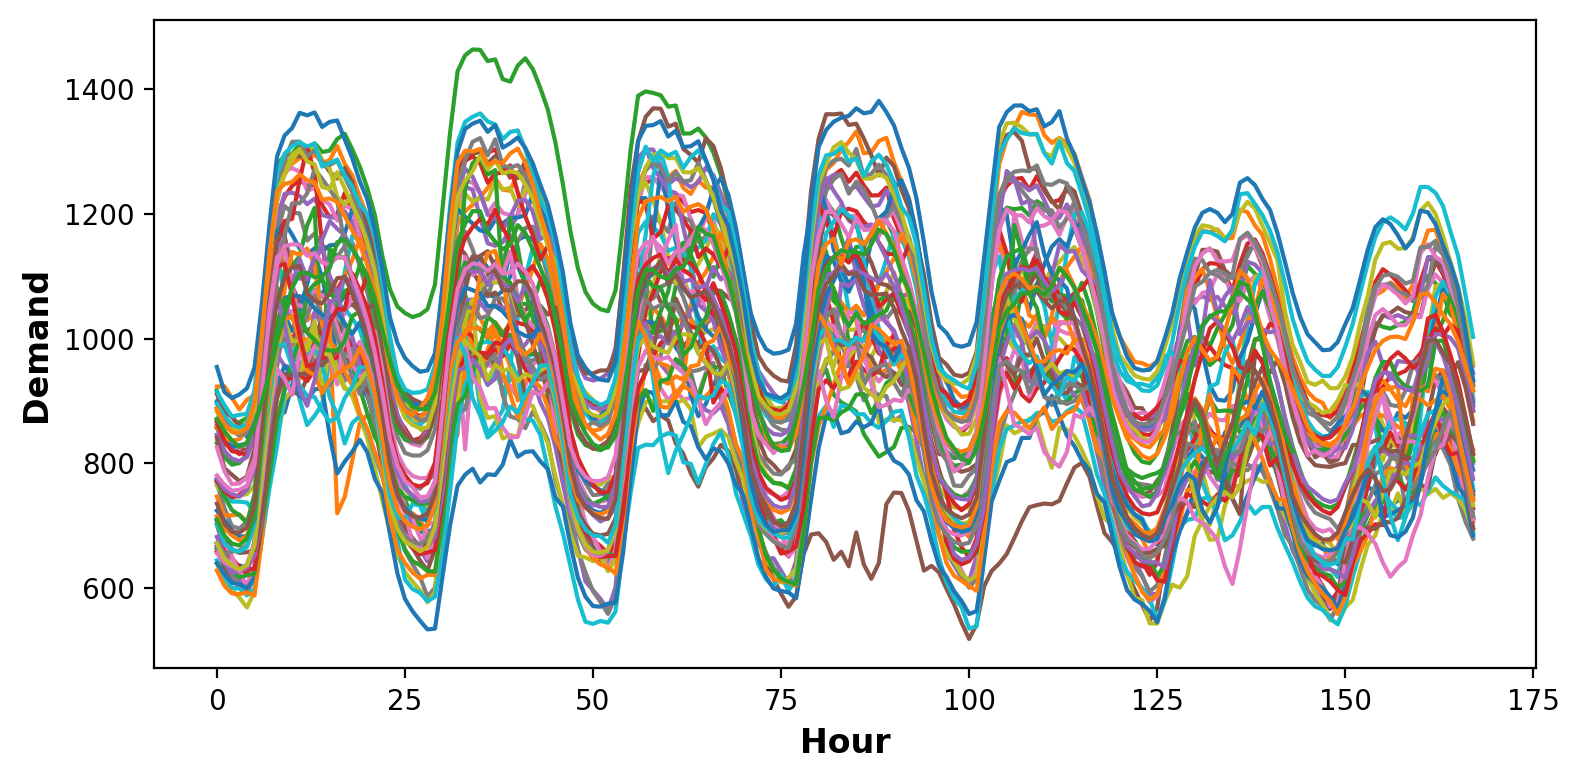

In [669]:
plt.figure(figsize=(8,4));
plt.xlabel('Hour')
plt.ylabel('Demand');
    
weeks = [g for n, g in demand.groupby(pd.Grouper(freq = 'W'))]
for i in range(len(weeks)):
    weeks[i].reset_index(drop=True, inplace=True)
    plt.plot(weeks[i])

plt.show()
plt.close("all")      


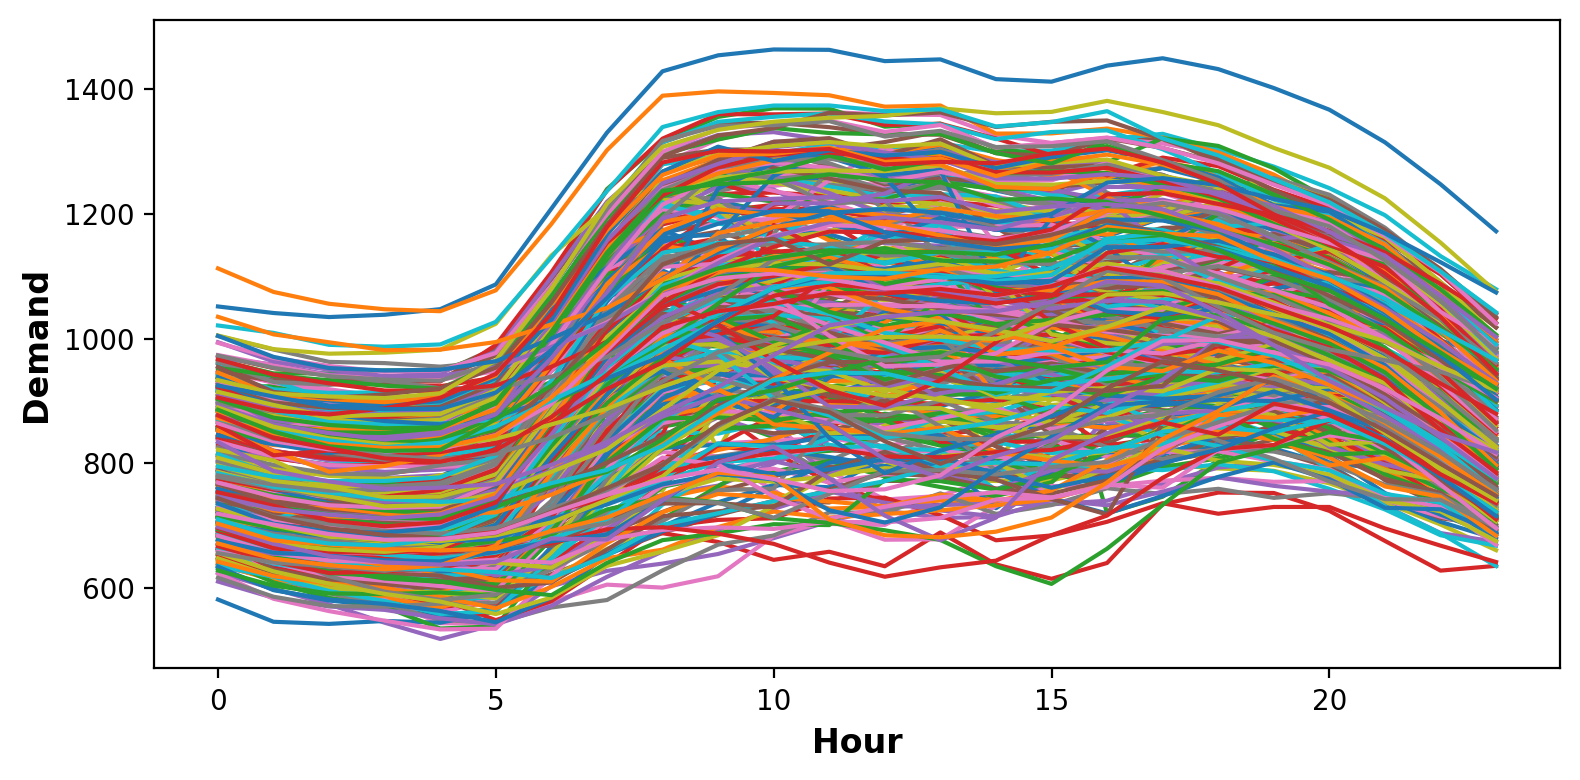

In [670]:
plt.figure(figsize=(8,4));
plt.xlabel('Hour')
plt.ylabel('Demand');
    
weeks = [g for n, g in demand.groupby(pd.Grouper(freq = 'D'))]
for i in range(len(weeks)):
    weeks[i].reset_index(drop=True, inplace=True)
    plt.plot(weeks[i])

plt.show()
plt.close("all")      


## Seasonality from decomposition

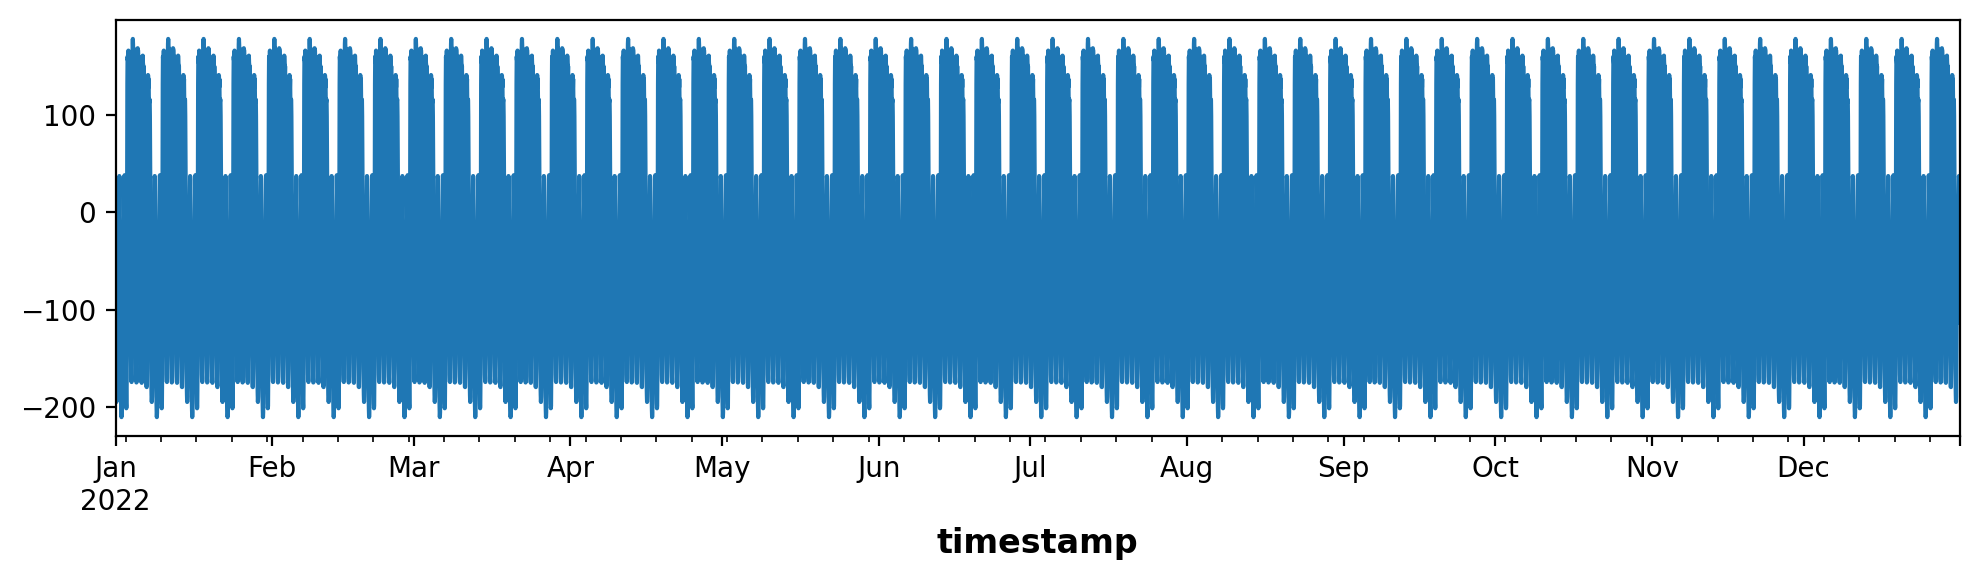

In [671]:
result=seasonal_decompose(demand, model='additive', period=24*7)
plt.figure(figsize=(10,3))
result.seasonal.plot();

# 🤝 Clustering for Creating Demand Profiles

Clustering groups **similar days (or hours)** together, so we can discover **typical demand patterns**. This is especially useful in energy:

* ⚡ To identify **typical daily load shapes** (e.g., weekdays vs weekends).
* 🏠 To classify customers by **consumption behavior**.
* 📊 To reduce data complexity by summarizing demand into a few representative clusters.

---

### 🔹 How it Works

1. **Prepare the data**:

   * Take daily demand curves (e.g., 24 hourly values per day).
   * Normalize each day (so clustering is about *shape*, not absolute size).

2. **Apply a clustering algorithm**:

   * **K-Means** (most common) → finds `k` typical demand profiles.
   * **Hierarchical clustering** → builds a tree of profiles.
   * **DBSCAN** → detects irregular demand days as anomalies.

3. **Interpret clusters**:

   * Each cluster represents a **profile** (e.g., “workday”, “weekend”, “holiday”).
   * The cluster centers = **typical demand shapes**.


## Weekly profile

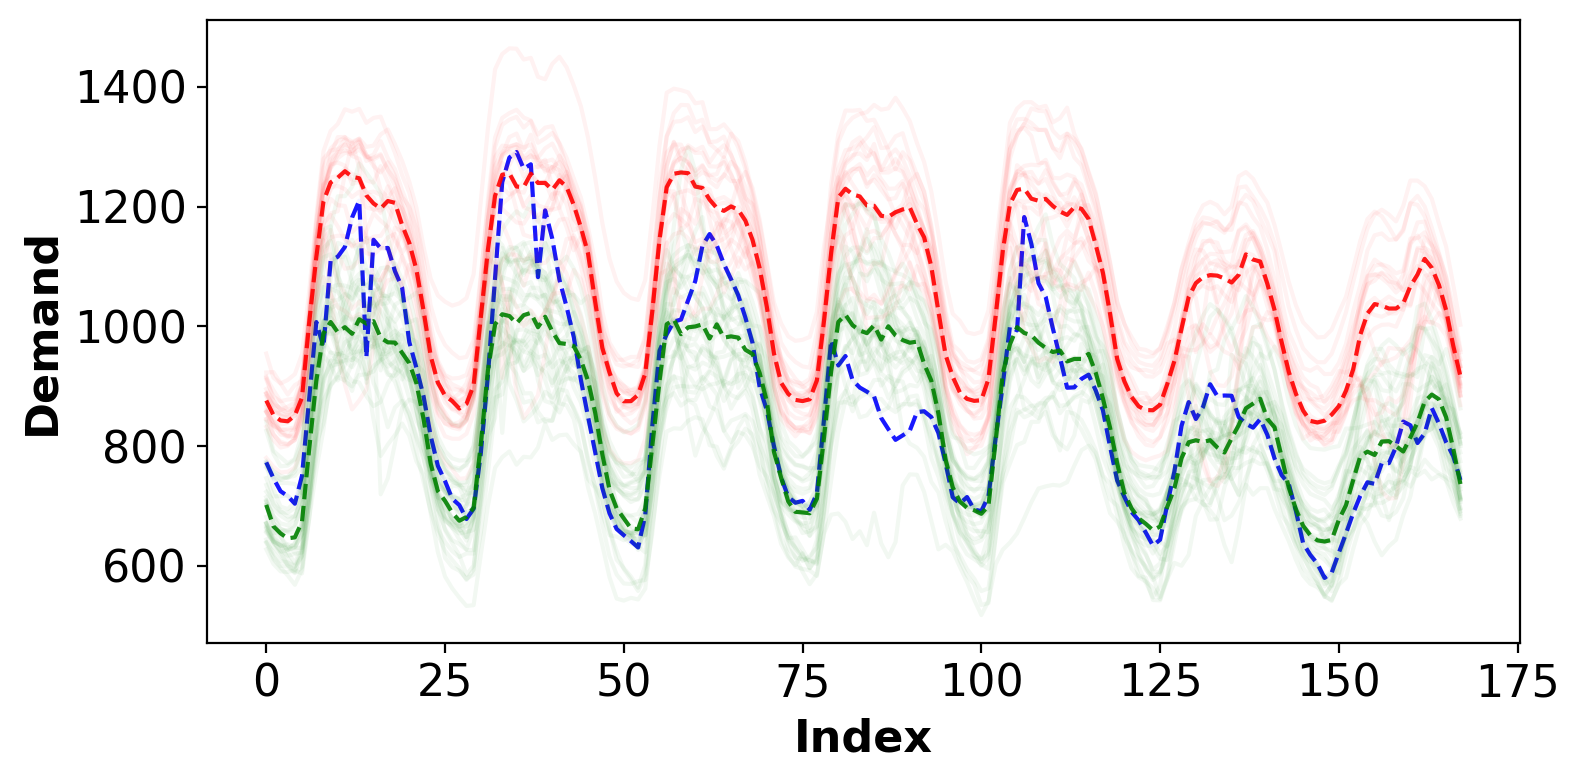

In [672]:
from sklearn.cluster import KMeans

def plot_clusters(data, title, c, f):
    periods = [g for n, g in data.groupby(pd.Grouper(freq = f))]

    for i in range(len(periods)):
        periods[i] = periods[i].rename(str(i))
        periods[i].reset_index(drop=True, inplace=True)

    df = pd.DataFrame(periods)
    df = df.dropna()

    
    kmeans = KMeans(n_clusters=c)
    cluster_found = kmeans.fit_predict(df)
    cluster_values, cluster_counts = np.unique(kmeans.labels_, return_counts=True)


    cluster_found_sr = pd.Series(cluster_found, name='cluster')
    df = df.set_index(cluster_found_sr, append=True )



    fig, ax= plt.subplots(1,1, figsize=(8,4))
    color_list = ['blue','red','green','black','orange','purple', 'cyan']
    color_list = color_list[0:(c)]
   

    
    for cluster, color in zip(cluster_values, color_list):
        df.xs(cluster, level=1).T.plot(
            ax=ax, legend=False, alpha=0.050, color=color, label= f'Cluster {cluster}'
        )
        
        median_centroid=df.xs(cluster, level=1).median()
        
        median_centroid.plot(
            ax=ax, color=color, alpha=0.9, ls='--'
        )
        

    ax.legend()
    plt.xlabel('Index', fontsize=16)
    plt.ylabel('Demand', fontsize=16)
    plt.legend('', frameon=False)
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    
    return plt;

plot_clusters(demand['demand'], 'Demand', 3, 'W');

## Daily profile

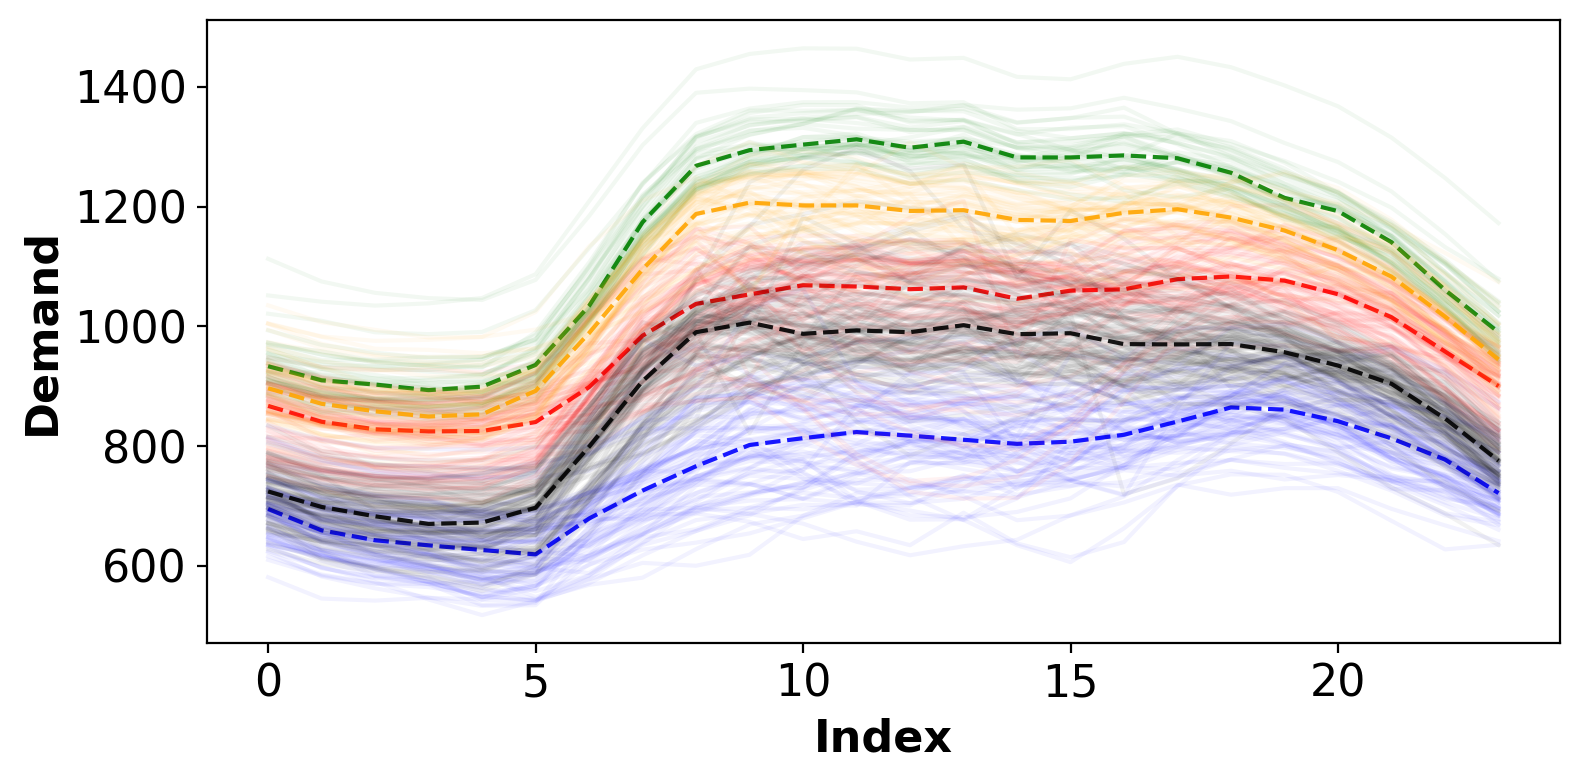

In [673]:
plot_clusters(demand['demand'], 'Consumption', 5, 'D');

## Estonian consumption

# 🔧 De-Trending and De-Seasonalizing

Many forecasting models (like ARIMA, regression, or ML methods) work best when the time series is **stationary** — meaning its statistical properties (mean, variance) don’t change over time.

* 📉 **Trend** → long-term increase or decrease in the series.
* 🔁 **Seasonality** → repeating patterns (daily, weekly, yearly).
  Removing these components = **detrending** and **deseasonalizing**.

---

## 📉 De-Trending

**Goal:** Remove the long-term upward/downward drift.

### Methods

* **Differencing:**

  $$
  y'_t = y_t - y_{t-1}
  $$

  Removes linear trend by taking first differences.

* **Regression on time:**
  Fit $y_t = a \cdot t + b$, then subtract the fitted trend.

* **Moving averages:**
  Use rolling mean to estimate trend, subtract it from the original series.


In [674]:
australia.head(10)

,electricity,time
datetime,,
1956-03-01,3923,0
1956-06-01,4436,1
1956-09-01,4806,2
1956-12-01,4418,3
1957-03-01,4339,4
1957-06-01,4811,5
1957-09-01,5259,6
1957-12-01,4735,7
1958-03-01,4608,8


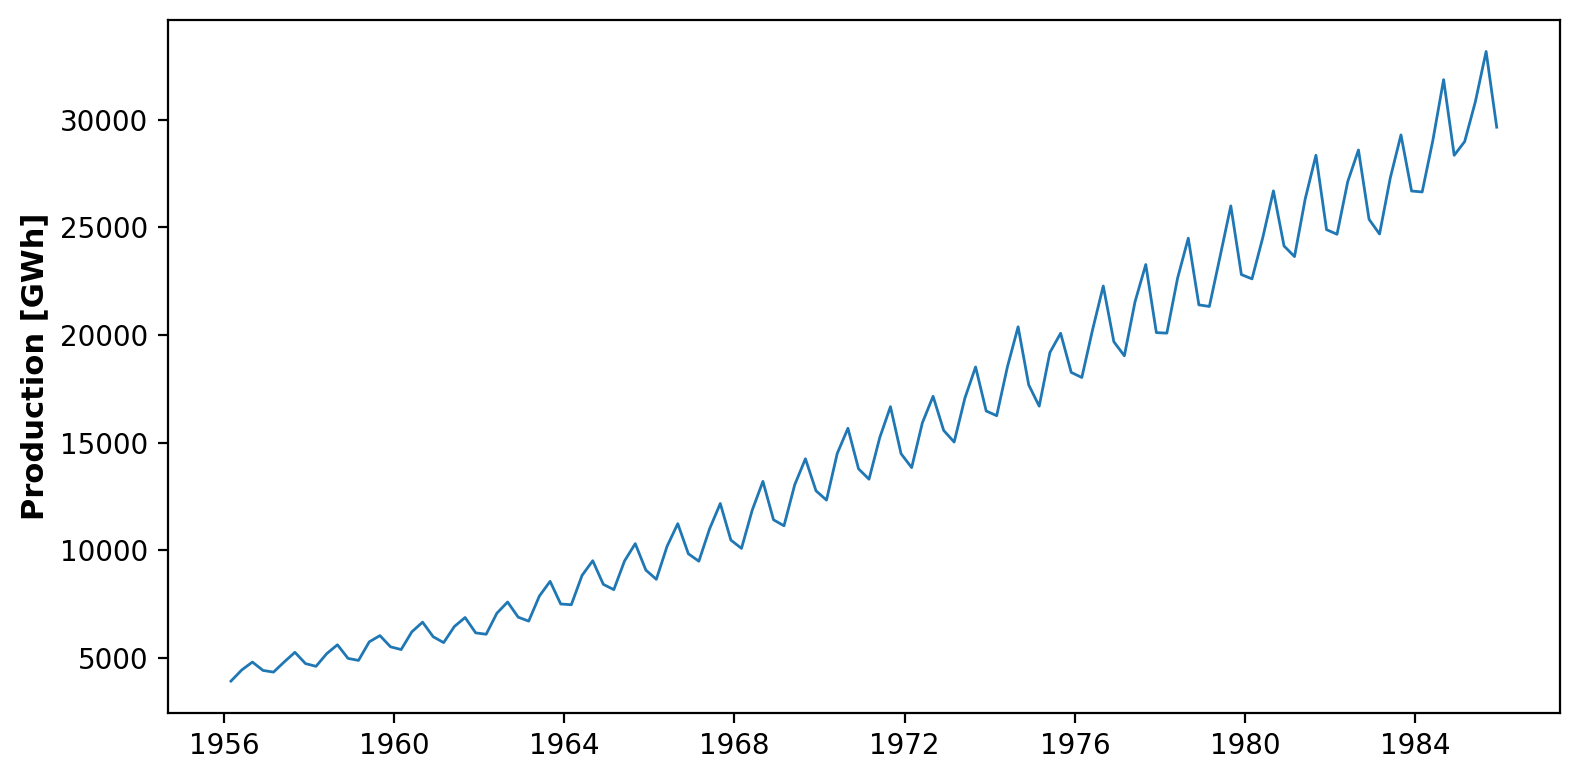

In [675]:
plt.figure(figsize=(8, 4))
plt.plot(australia['electricity'], lw=1)
plt.ylabel('Production [GWh]', fontsize=11)
plt.show()

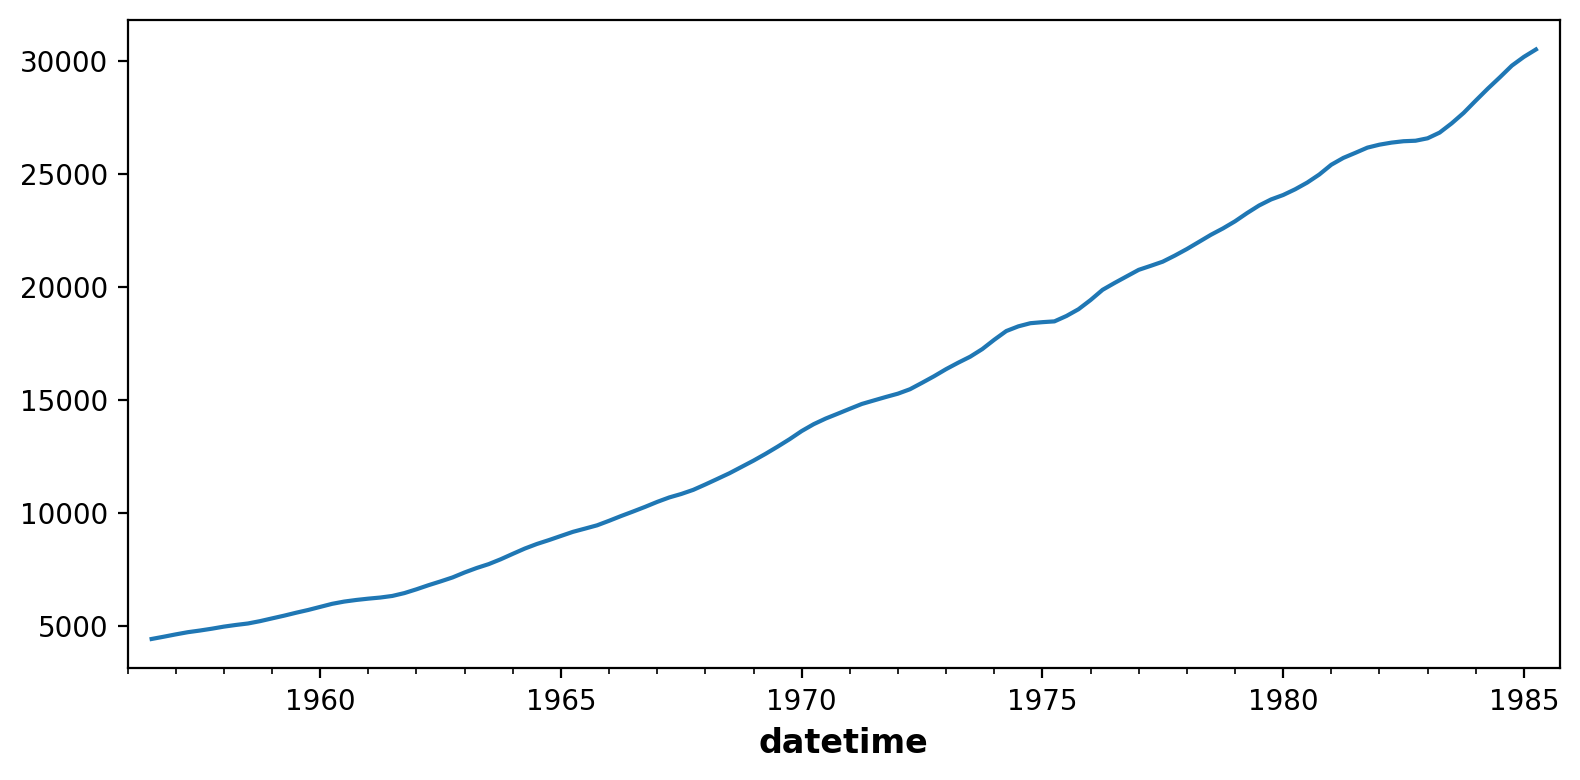

In [676]:
au_result = seasonal_decompose(australia['electricity'], model='additive', period=4)
plt.figure(figsize=(8,4))
au_result.trend.plot();

In [677]:
de_trend = australia['electricity']- au_result.trend

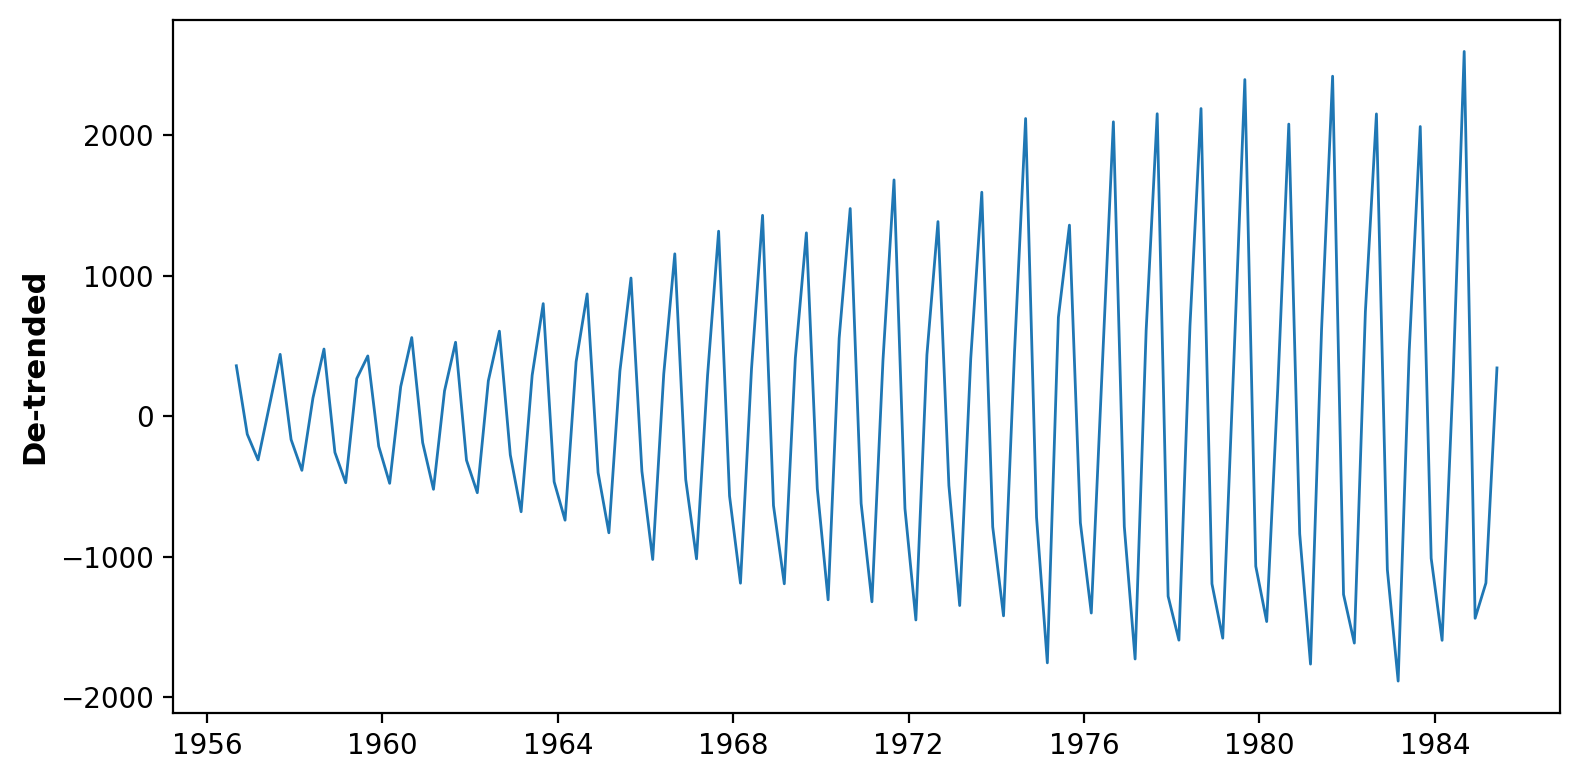

In [678]:
plt.figure(figsize=(8, 4))
plt.plot(de_trend, lw=1)
plt.ylabel('De-trended', fontsize=11)
plt.show()


## 🔁 De-Seasonalizing

**Goal:** Remove repeating cycles (daily, weekly, annual).

### Methods

* **Seasonal differencing:**

  $$
  y'_t = y_t - y_{t-s}
  $$

  where $s$ is the seasonal period (24 for daily, 168 for weekly).

* **Divide by seasonal indices:**
  Estimate seasonal factors (e.g., average demand by month), then divide the series by them.

* **Classical decomposition (additive/multiplicative):**
  Separate series into trend + seasonal + remainder.

---

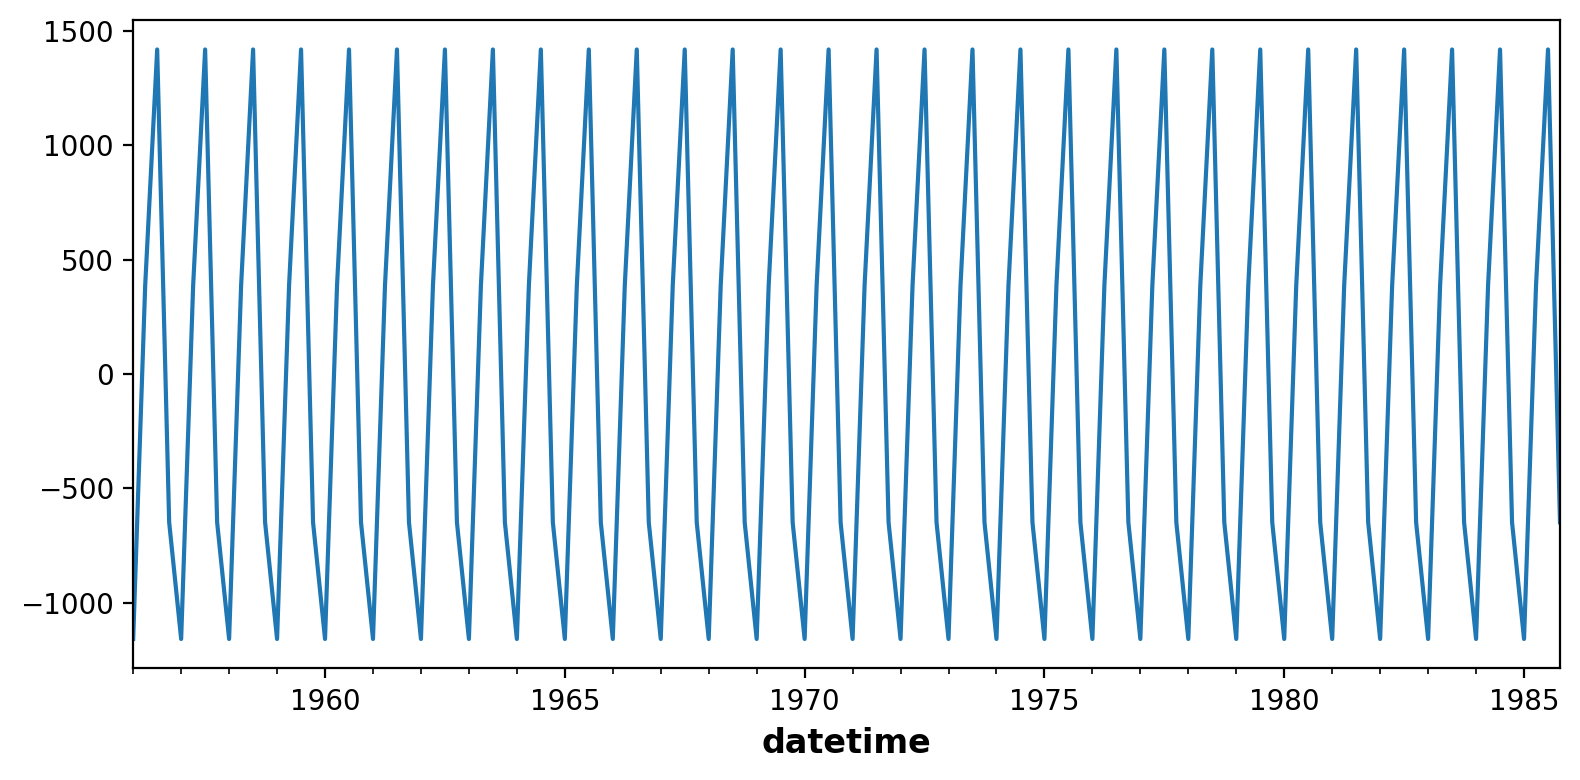

In [679]:
plt.figure(figsize=(8,4))
au_result.seasonal.plot();

In [680]:
de_trend = de_trend - au_result.seasonal

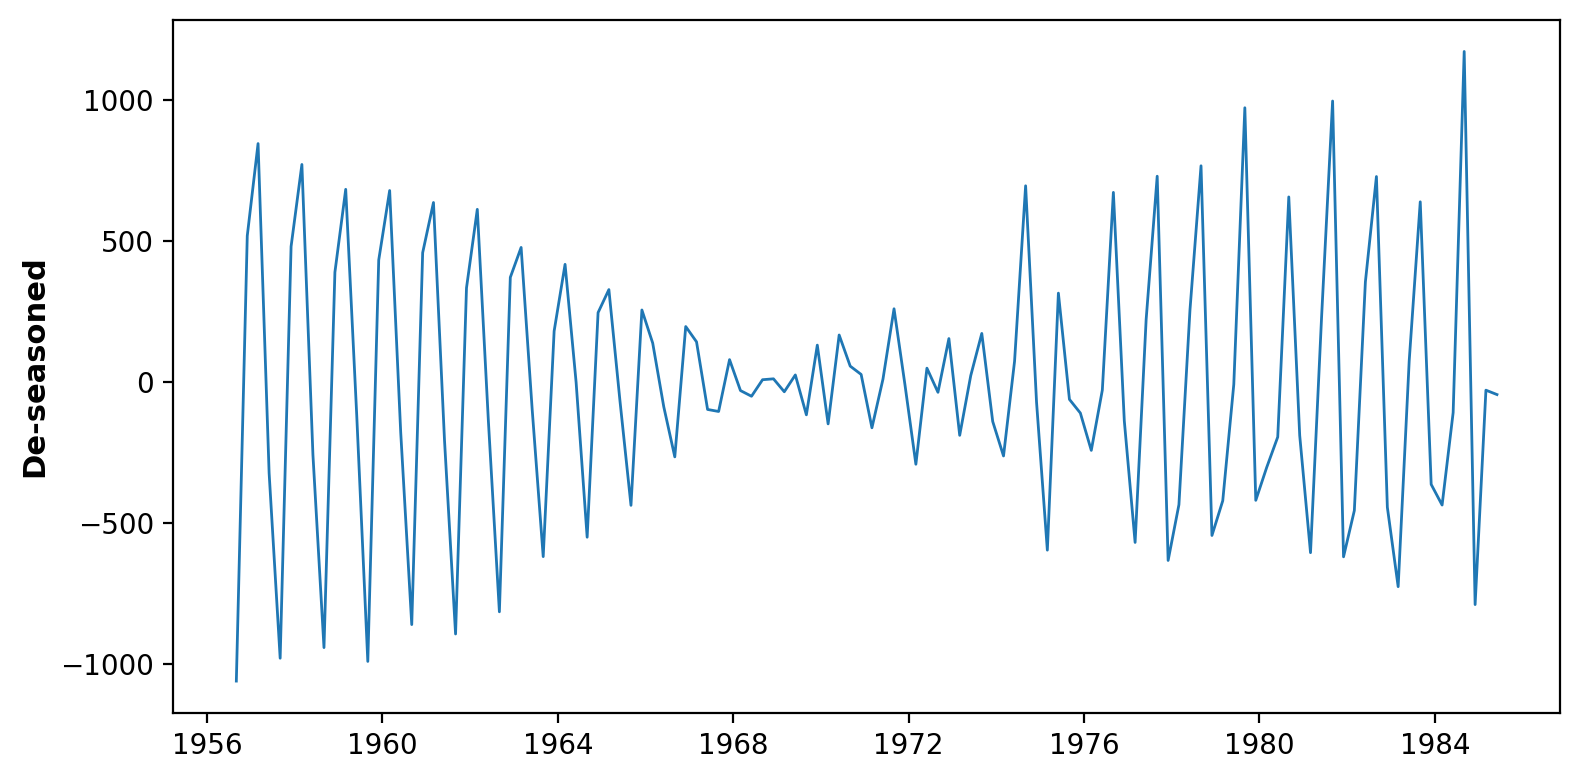

In [681]:
plt.figure(figsize=(8, 4))
plt.plot(de_trend, lw=1)
plt.ylabel('De-seasoned', fontsize=11)
plt.show()


---

## ✅ Summary

* **De-trending** removes long-term growth/decline.
* **De-seasonalizing** removes repeating patterns.
* Both steps help models focus on **stationary residuals**, which are easier to forecast.
* Once forecasting is done, you can **add back the trend and seasonality** to reconstruct final predictions.
